# Explainable AI for Stellar Object Classification
**Dataset:** SDSS-mirrored synthetic photometric survey data\
**Objects:** STAR | GALAXY | QUASAR\
**Model:** Random Forest (200 trees)\
**XAI:** SHAP (global summary + local waterfall + interaction), LIME (local per-sample), Permutation Importance

In [ ]:
# 1. Environment Setup
!pip install shap lime

### Imports and Global Configurations
Setting up the environment, libraries, and global plot styling.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.inspection import permutation_importance
import shap
import lime, lime.lime_tabular

np.random.seed(42)

SAVE = './figures'
os.makedirs(SAVE, exist_ok=True)

COLORS = dict(STAR='#FFD700', GALAXY='#4FC3F7', QUASAR='#EF5350',
              bg='#0D1117', text='#E8EAF6', panel='#161B22', accent='#7C4DFF')
CLASS_NAMES  = ['STAR', 'GALAXY', 'QUASAR']
CLASS_COLORS = [COLORS['STAR'], COLORS['GALAXY'], COLORS['QUASAR']]

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],  'axes.facecolor': COLORS['panel'],
    'axes.edgecolor':   '#30363D',     'axes.labelcolor': COLORS['text'],
    'xtick.color':      COLORS['text'],'ytick.color':    COLORS['text'],
    'text.color':       COLORS['text'],'grid.color':     '#21262D',
    'grid.linewidth':   0.5,           'font.size':       10,
    'axes.titlesize':   12,            'axes.titleweight':'bold',
})

## Part 1: Dataset Generation
Creating the synthetic SDSS photometric dataset and calculating derived color indices (u-g, g-r, r-i, i-z).

In [ ]:
def make_class(n, u, g, r, i, z, z_fn):
    return np.column_stack([
        np.random.normal(u,1.8,n), np.random.normal(g,1.7,n),
        np.random.normal(r,1.6,n), np.random.normal(i,1.5,n),
        np.random.normal(z,1.5,n), z_fn(n),
        np.random.randint(100,8000,n).astype(float),
        np.random.randint(266,3000,n).astype(float),
        np.random.randint(51600,57000,n).astype(float),
        np.random.randint(1,1000,n).astype(float)
    ])

n_star, n_gal, n_qso = 4000, 4000, 2000
X_raw = np.vstack([
    make_class(n_star,19.2,18.5,18.1,17.9,17.7, lambda n: np.abs(np.random.normal(0,.002,n))),
    make_class(n_gal, 20.5,19.4,18.8,18.4,18.1, lambda n: np.clip(np.random.exponential(.12,n),0,.8)),
    make_class(n_qso, 20.0,19.6,19.5,19.3,19.0, lambda n: np.random.uniform(.1,5.,n))
])
y_raw = np.array(['STAR']*n_star + ['GALAXY']*n_gal + ['QUASAR']*n_qso)

FEAT_BASE = ['u_mag','g_mag','r_mag','i_mag','z_mag','redshift','run','plate','MJD','fiber_id']
df = pd.DataFrame(X_raw, columns=FEAT_BASE)
df['class'] = y_raw
df['u_g'] = df['u_mag'] - df['g_mag']
df['g_r'] = df['g_mag'] - df['r_mag']
df['r_i'] = df['r_mag'] - df['i_mag']
df['i_z'] = df['i_mag'] - df['z_mag']
FEAT = FEAT_BASE + ['u_g','g_r','r_i','i_z']

print(f"Dataset Shape: {df.shape}   Missing Values: {df.isnull().sum().sum()}")
print(df['class'].value_counts().to_string())

Dataset Shape: (10000, 15)   Missing Values: 0
class
STAR      4000
GALAXY    4000
QUASAR    2000


### EDA: Class and Redshift Distributions

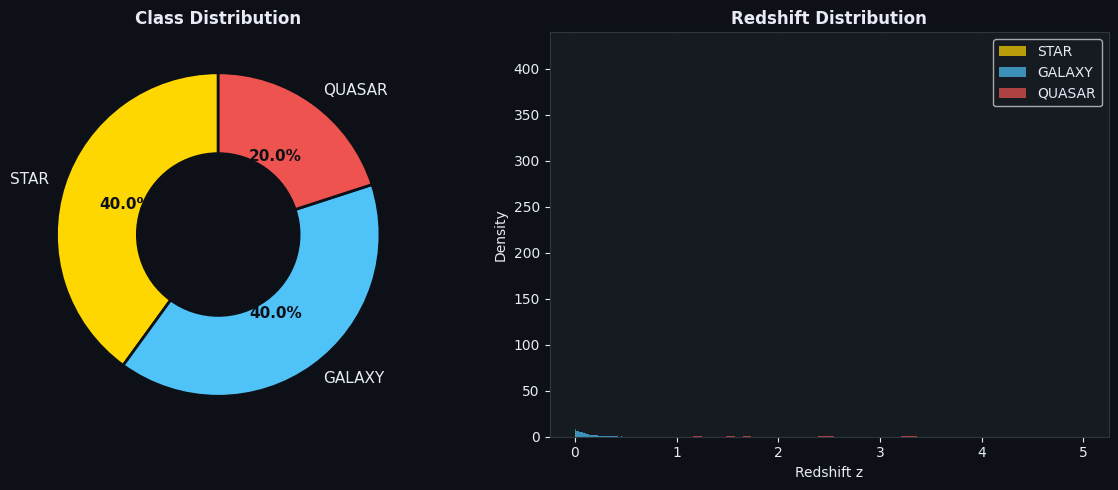

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class Distribution
sizes = df['class'].value_counts()
wedges,_,atext = axes[0].pie(sizes, labels=sizes.index, colors=CLASS_COLORS,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5, edgecolor=COLORS['bg'], linewidth=2),
    textprops={'color':COLORS['text'],'fontsize':11})
for at in atext: at.set_color(COLORS['bg']); at.set_fontweight('bold')
axes[0].set_title('Class Distribution')

# Redshift Distribution
for c,col in zip(CLASS_NAMES,CLASS_COLORS):
    axes[1].hist(df[df['class']==c]['redshift'],bins=60,alpha=0.7,
            color=col,label=c,density=True,edgecolor='none')
axes[1].set_title('Redshift Distribution'); axes[1].set_xlabel('Redshift z')
axes[1].set_ylabel('Density'); axes[1].legend(facecolor=COLORS['panel']); axes[1].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

### EDA: Color-Color Diagram and Feature Correlations

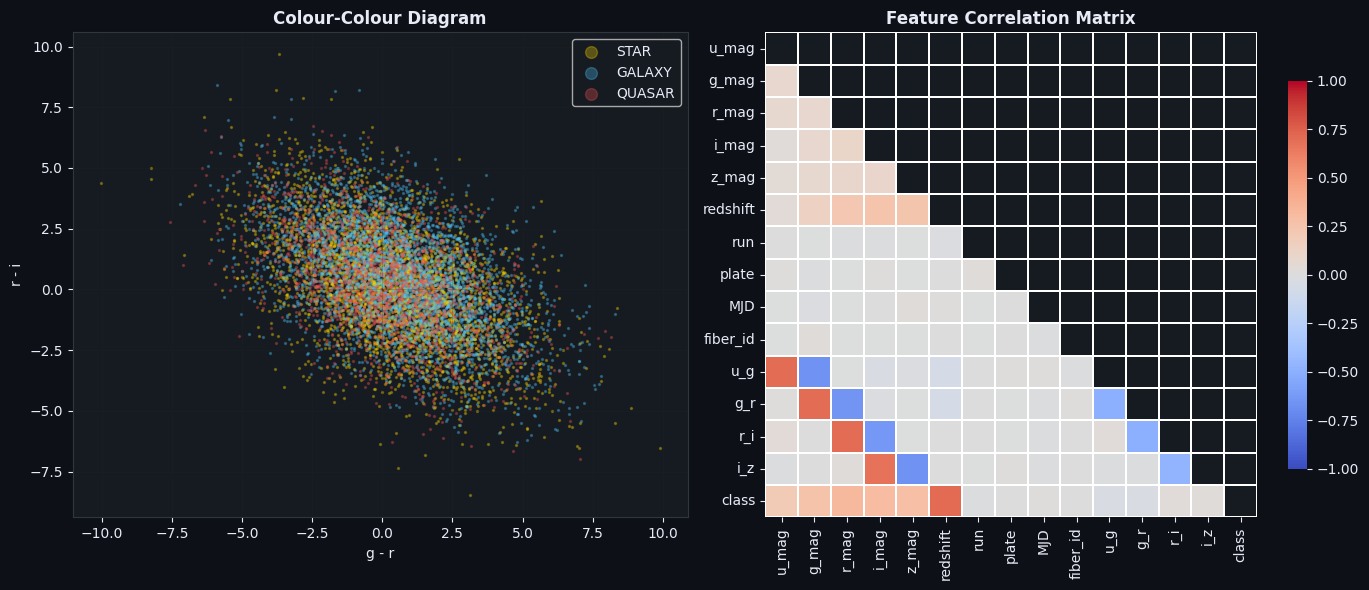

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colour-Colour Diagram
for c,col in zip(CLASS_NAMES,CLASS_COLORS):
    s=df[df['class']==c]
    axes[0].scatter(s['g_r'],s['r_i'],c=col,s=2,alpha=0.3,label=c)
axes[0].set_title('Colour-Colour Diagram'); axes[0].set_xlabel('g - r'); axes[0].set_ylabel('r - i')
axes[0].legend(facecolor=COLORS['panel'],markerscale=6); axes[0].grid(True,alpha=0.3)

# Feature Correlation Matrix
corr = df[FEAT+['class']].replace({'STAR':0,'GALAXY':1,'QUASAR':2}).corr()
mask = np.triu(np.ones_like(corr,bool))
sns.heatmap(corr,ax=axes[1],cmap='coolwarm',center=0,vmin=-1,vmax=1,
            mask=mask,linewidths=0.3,cbar_kws={'shrink':0.8})
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

## Part 2: Data Preprocessing & Model Training
Encoding targets, scaling features, and training the Random Forest.

In [ ]:
X = df[FEAT].values
le = LabelEncoder()
y = le.fit_transform(df['class'].values)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=4,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_tr_s, y_tr)

y_pred = rf.predict(X_te_s)
y_proba = rf.predict_proba(X_te_s)
acc = accuracy_score(y_te, y_pred)
f1 = f1_score(y_te, y_pred, average='weighted')
cv  = cross_val_score(rf, X_tr_s, y_tr, cv=5, scoring='accuracy')

print(f"Accuracy: {acc:.4f}  |  F1 (weighted): {f1:.4f}")
print(f"5-Fold CV Mean: {cv.mean():.4f} +/- {cv.std():.4f}\n")
print(classification_report(y_te, y_pred, target_names=le.classes_))

Accuracy: 0.9605  |  F1 (weighted): 0.9603
5-Fold CV Mean: 0.9616 +/- 0.0034

              precision    recall  f1-score   support

      GALAXY       0.95      0.95      0.95       800
      QUASAR       0.98      0.91      0.94       400
        STAR       0.96      0.99      0.98       800

    accuracy                           0.96      2000
   macro avg       0.96      0.95      0.96      2000
weighted avg       0.96      0.96      0.96      2000



### Plot Model Evaluation Metrics

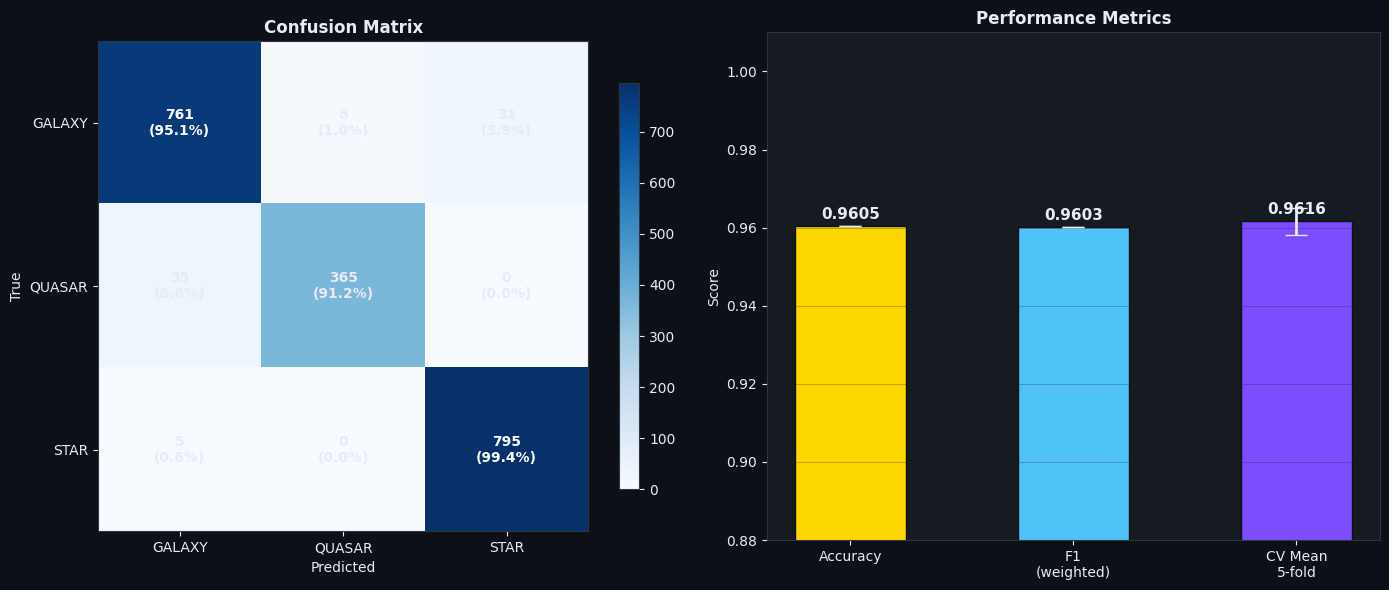

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_te,y_pred)
im = axes[0].imshow(cm,cmap='Blues')
axes[0].set_xticks(range(3)); axes[0].set_yticks(range(3))
axes[0].set_xticklabels(le.classes_); axes[0].set_yticklabels(le.classes_)
for i in range(3):
    for j in range(3):
        axes[0].text(j,i,f'{cm[i,j]}\n({cm[i,j]/cm[i].sum()*100:.1f}%)',
                ha='center',va='center',fontsize=10,
                color='white' if cm[i,j]>cm.max()/2 else COLORS['text'],fontweight='bold')
plt.colorbar(im,ax=axes[0],shrink=0.8)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix')

# Performance Metrics Bar
mnames=['Accuracy','F1\n(weighted)','CV Mean\n5-fold']
vvals=[acc,f1,cv.mean()]
errs=[0,0,cv.std()]
bars=axes[1].bar(mnames,vvals,color=[COLORS['STAR'],COLORS['GALAXY'],COLORS['accent']],
            width=0.5,edgecolor=COLORS['bg'])
axes[1].errorbar(mnames,vvals,yerr=errs,fmt='none',color=COLORS['text'],capsize=8,linewidth=2)
axes[1].set_ylim(0.88,1.01); axes[1].set_ylabel('Score'); axes[1].set_title('Performance Metrics')
axes[1].grid(True,axis='y',alpha=0.4)
for b,v in zip(bars,vvals):
    axes[1].text(b.get_x()+b.get_width()/2,b.get_height()+0.001,
            f'{v:.4f}',ha='center',va='bottom',fontweight='bold',fontsize=11)

plt.tight_layout()
plt.show()

## Part 3a: Global Explanations
Calculating SHAP values and visualizing global feature importance.

In [ ]:
explainer = shap.TreeExplainer(rf)
# Compute SHAP values on a subset of test data to save time in notebook environments
shap_vals = explainer.shap_values(X_te_s[:500])
print(f"SHAP shape: {np.array(shap_vals).shape}")

def sv_cls(ci): return shap_vals[:,:,ci]

SHAP shape: (500, 14, 3)


### SHAP Global Importance (Per Class)

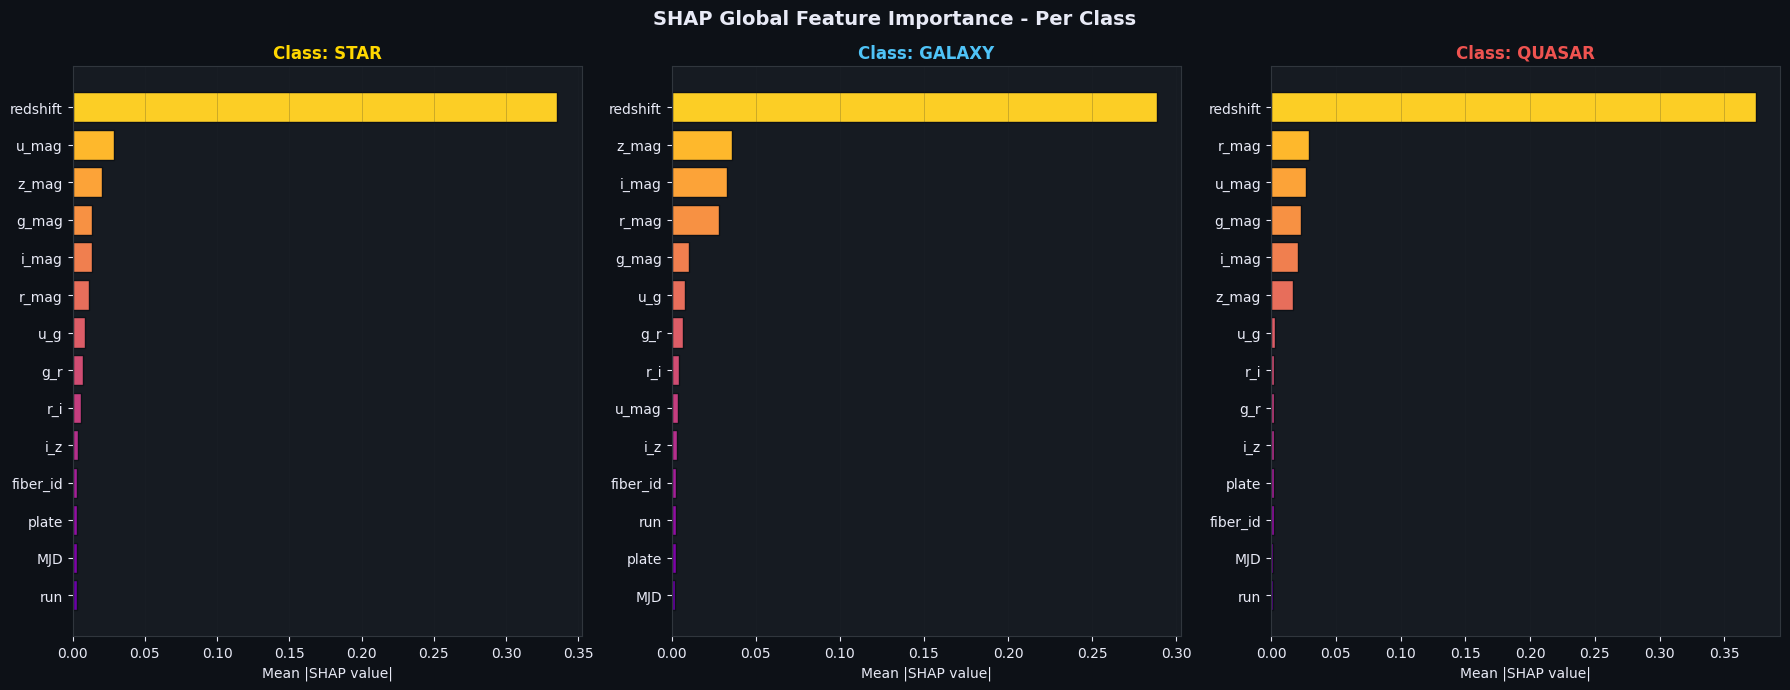

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(18,7))
fig.suptitle('SHAP Global Feature Importance - Per Class',fontsize=14,fontweight='bold')

for ci,(cname,col) in enumerate(zip(CLASS_NAMES,CLASS_COLORS)):
    ax = axes[ci]
    ms = np.abs(sv_cls(ci)).mean(axis=0)
    idx = np.argsort(ms)
    ax.barh([FEAT[i] for i in idx],ms[idx],
            color=plt.cm.plasma(np.linspace(0.2,0.9,len(idx))),edgecolor=COLORS['bg'])
    ax.set_title(f'Class: {cname}',color=col)
    ax.set_xlabel('Mean |SHAP value|'); ax.grid(True,axis='x',alpha=0.3)

plt.tight_layout()
plt.show()

### Permutation Feature Importance

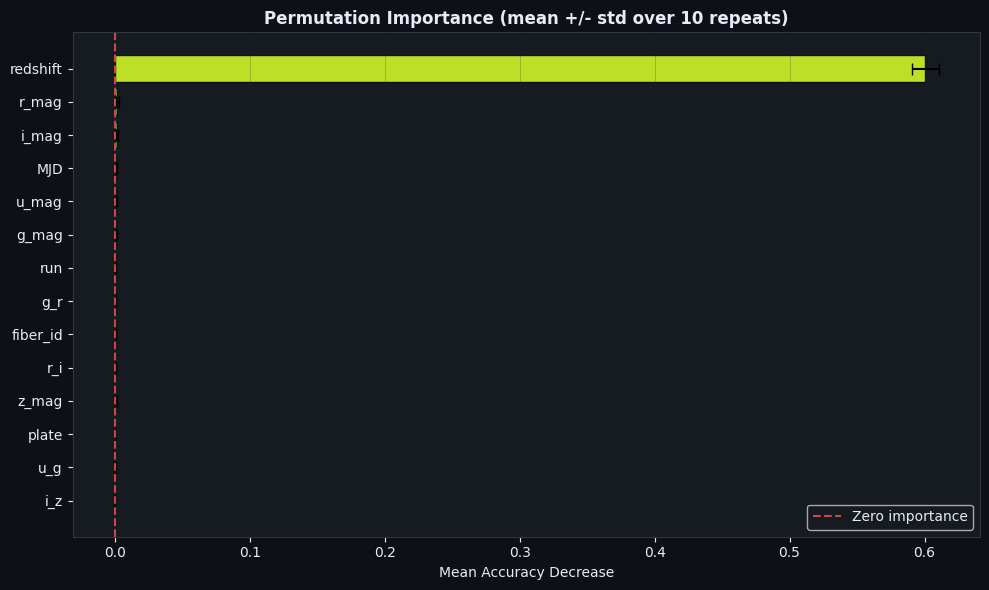

In [ ]:
perm = permutation_importance(rf,X_te_s,y_te,n_repeats=10,random_state=42,n_jobs=-1)
sidx = perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10,6))
ax.barh([FEAT[i] for i in sidx],perm.importances_mean[sidx],
        xerr=perm.importances_std[sidx],
        color=plt.cm.viridis(np.linspace(0.1,0.9,len(sidx))),
        edgecolor=COLORS['bg'],capsize=4)
ax.axvline(0,color='#FF5252',linestyle='--',linewidth=1.5,alpha=0.8,label='Zero importance')
ax.set_xlabel('Mean Accuracy Decrease')
ax.set_title('Permutation Importance (mean +/- std over 10 repeats)')
ax.legend(facecolor=COLORS['panel']); ax.grid(True,axis='x',alpha=0.3)

plt.tight_layout()
plt.show()

### SHAP Beeswarm Plot (Aggregated)

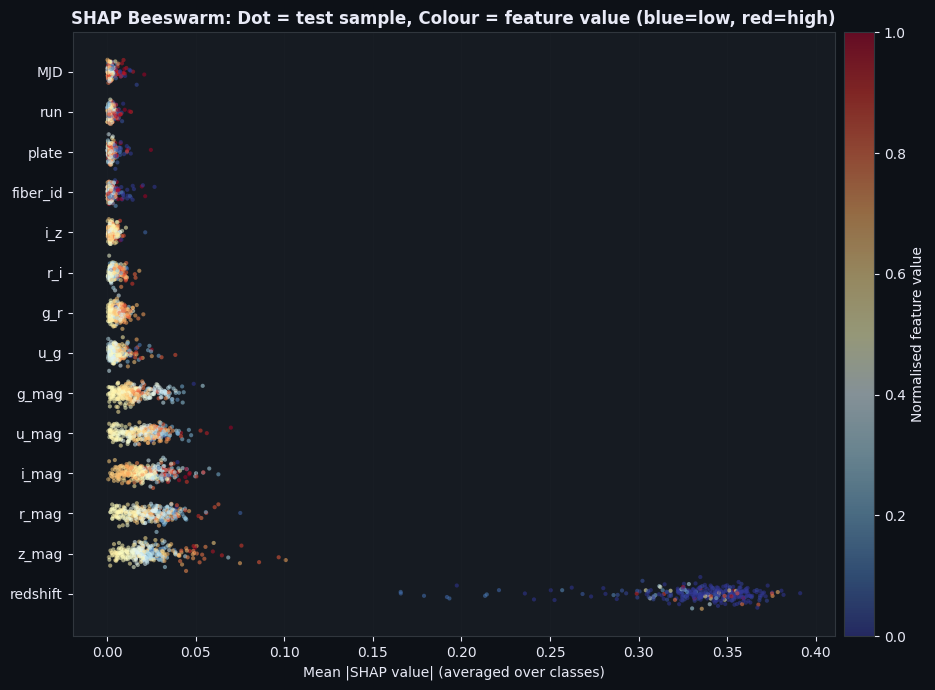

In [ ]:
shap_abs_mean = np.abs(shap_vals).mean(axis=2)
global_rank   = np.argsort(shap_abs_mean.mean(axis=0))[::-1]
feat_ranked   = [FEAT[i] for i in global_rank]

fig, ax = plt.subplots(figsize=(10, 7))
sc_obj = None
n_pts = 300

for fpos, fi in enumerate(global_rank):
    vals   = shap_abs_mean[:n_pts, fi]
    jitter = np.random.normal(fpos, 0.12, n_pts)
    fv_raw = X_te_s[:n_pts, fi].astype(float)
    fv_min, fv_max = fv_raw.min(), fv_raw.max()
    fv_norm = (fv_raw - fv_min) / (fv_max - fv_min + 1e-8)
    sc_obj = ax.scatter(vals.tolist(), jitter.tolist(),
                        c=fv_norm.tolist(), cmap='RdYlBu_r',
                        s=9, alpha=0.55, linewidths=0, vmin=0.0, vmax=1.0)

ax.set_yticks(range(len(FEAT))); ax.set_yticklabels(feat_ranked)
ax.set_xlabel('Mean |SHAP value| (averaged over classes)')
ax.set_title('SHAP Beeswarm: Dot = test sample, Colour = feature value (blue=low, red=high)')
ax.grid(True,axis='x',alpha=0.3)
if sc_obj is not None:
    cb = plt.colorbar(sc_obj,ax=ax,pad=0.01)
    cb.set_label('Normalised feature value')

plt.tight_layout()
plt.show()

## Part 3b: Local Explanations
Selecting individual samples to explain specific predictions.

In [ ]:
target = {}
# Grab one specific correct prediction per class to analyze
for ci, cname in enumerate(le.classes_):
    pool = np.where((y_te==ci) & (y_pred==ci))[0]
    target[cname] = pool[5]
print("Selected Sample Indices for Local Explanation:", target)

Selected Sample Indices for Local Explanation: {'GALAXY': np.int64(14), 'QUASAR': np.int64(35), 'STAR': np.int64(8)}


### SHAP Local Waterfall Plots

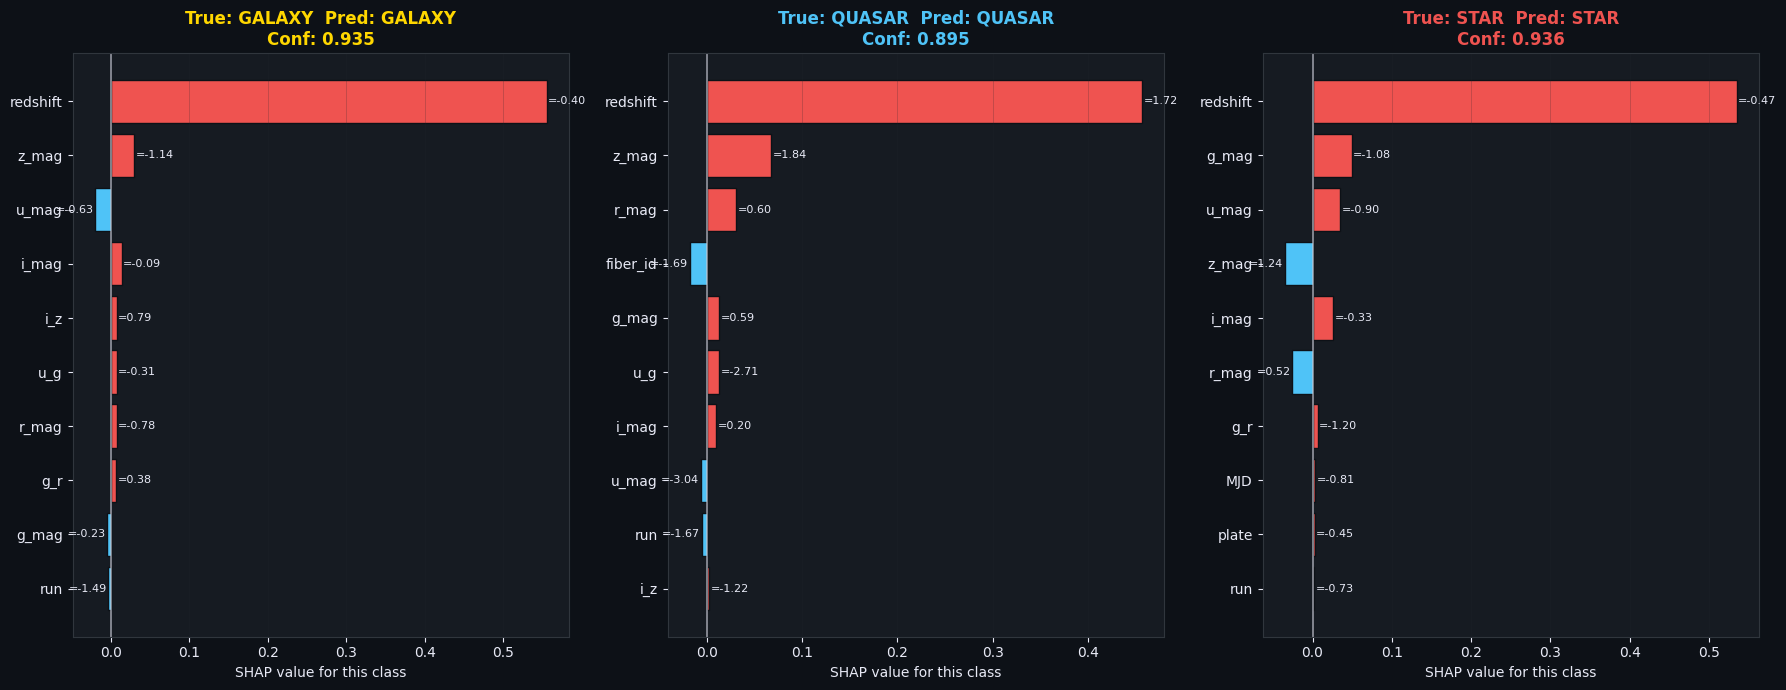

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(18,7))

for axi, (clabel, s_idx) in enumerate(target.items()):
    ci  = le.transform([clabel])[0]
    ax  = axes[axi]
    sv_s = shap_vals[s_idx, :, ci]
    xv   = X_te_s[s_idx]
    order = np.argsort(np.abs(sv_s))[::-1][:10]
    fnames = [FEAT[i] for i in order]
    sv_ord = sv_s[order]; xv_ord = xv[order]
    colors = [COLORS['QUASAR'] if v>0 else COLORS['GALAXY'] for v in sv_ord[::-1]]
    ax.barh(fnames[::-1], sv_ord[::-1].tolist(), color=colors, edgecolor=COLORS['bg'])
    ax.axvline(0,color=COLORS['text'],linewidth=1.2,alpha=0.6)
    ax.set_title(f'True: {clabel}  Pred: {le.classes_[y_pred[s_idx]]}\nConf: {y_proba[s_idx,ci]:.3f}',
                 color=CLASS_COLORS[axi])
    ax.set_xlabel('SHAP value for this class'); ax.grid(True,axis='x',alpha=0.3)
    for i,(bv,fv) in enumerate(zip(sv_ord[::-1], xv_ord[::-1])):
        ax.text(float(bv)+(0.002 if bv>=0 else -0.002), i,
                f'={float(fv):.2f}',va='center',fontsize=8,
                ha='left' if bv>=0 else 'right')

plt.tight_layout()
plt.show()

### LIME Local Explanations

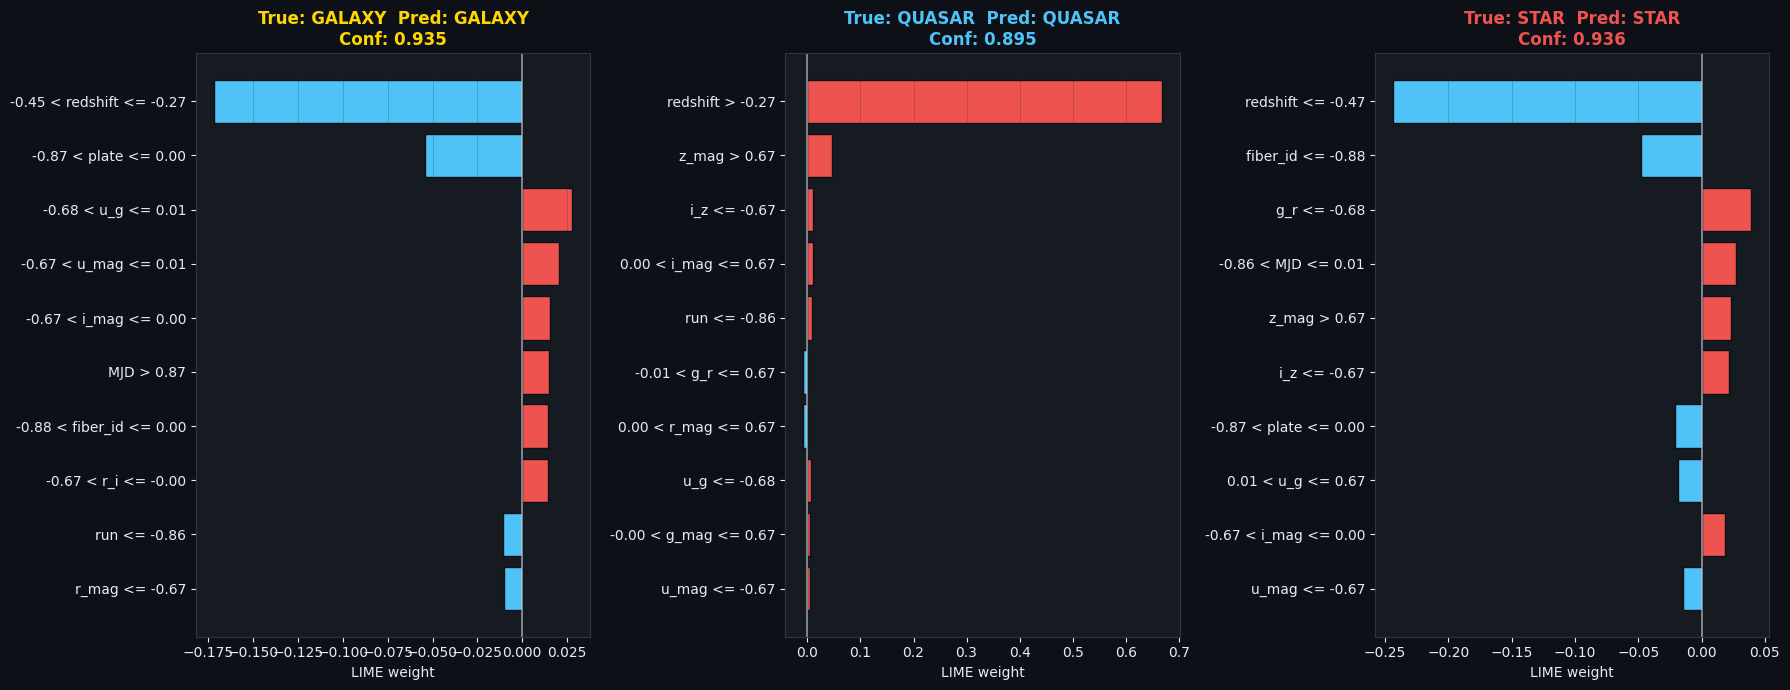

In [ ]:
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_tr_s, feature_names=FEAT,
    class_names=list(le.classes_), mode='classification',
    discretize_continuous=True, random_state=42)

fig, axes = plt.subplots(1,3,figsize=(18,7))

for axi, (clabel, s_idx) in enumerate(target.items()):
    ci  = le.transform([clabel])[0]
    ax  = axes[axi]
    exp = lime_exp.explain_instance(X_te_s[s_idx],rf.predict_proba,
                                     num_features=10,num_samples=800)
    avail = exp.available_labels()
    label_use = ci if ci in avail else avail[0]
    ll = exp.as_list(label=label_use)[:10]
    fl = [e[0] for e in ll]; wl = [e[1] for e in ll]
    colors = [COLORS['QUASAR'] if w>0 else COLORS['GALAXY'] for w in wl[::-1]]
    ax.barh(fl[::-1], wl[::-1], color=colors, edgecolor=COLORS['bg'])
    ax.axvline(0,color=COLORS['text'],linewidth=1.2,alpha=0.6)
    ax.set_title(f'True: {clabel}  Pred: {le.classes_[y_pred[s_idx]]}\nConf: {y_proba[s_idx].max():.3f}',
                 color=CLASS_COLORS[axi])
    ax.set_xlabel('LIME weight'); ax.grid(True,axis='x',alpha=0.3)

plt.tight_layout()
plt.show()

### Decision Boundary (PCA 2D Projection)

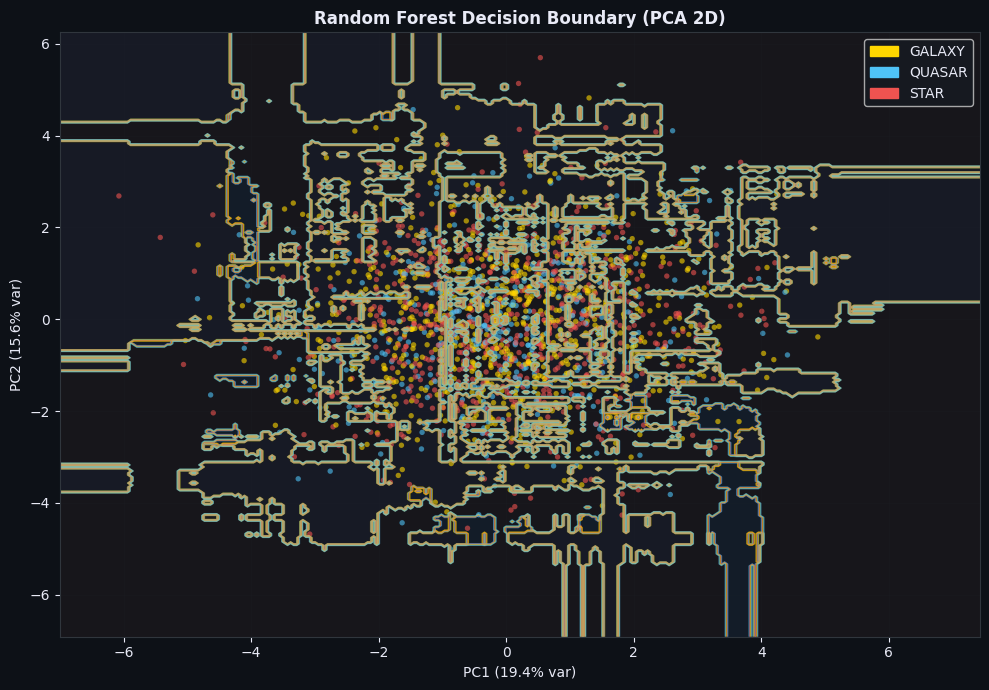

In [ ]:
pca  = PCA(n_components=2,random_state=42)
Xtr2 = pca.fit_transform(X_tr_s); Xte2 = pca.transform(X_te_s)
rf2d = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
rf2d.fit(Xtr2,y_tr)

x0,x1 = Xtr2[:,0].min()-1, Xtr2[:,0].max()+1
y0,y1 = Xtr2[:,1].min()-1, Xtr2[:,1].max()+1
xx,yy = np.meshgrid(np.linspace(x0,x1,300),np.linspace(y0,y1,300))
Z = rf2d.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10,7))
ax.contourf(xx,yy,Z,alpha=0.30,cmap=ListedColormap(['#1a1a2e','#0d2137','#1a0d0d']))
ax.contour(xx,yy,Z,colors=[COLORS['STAR'],COLORS['GALAXY'],COLORS['QUASAR']],linewidths=1.0,alpha=0.6)
ax.scatter(Xte2[:,0],Xte2[:,1],c=y_te,cmap=ListedColormap(CLASS_COLORS),s=15,alpha=0.6,linewidths=0)
patches = [mpatches.Patch(color=c,label=n) for c,n in zip(CLASS_COLORS,le.classes_)]
ax.legend(handles=patches,facecolor=COLORS['panel'])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Random Forest Decision Boundary (PCA 2D)')
ax.grid(True,alpha=0.2)

plt.tight_layout()
plt.show()

## Part 4: Consolidation & Export
Generating the comprehensive dashboard and saving metric artifacts.

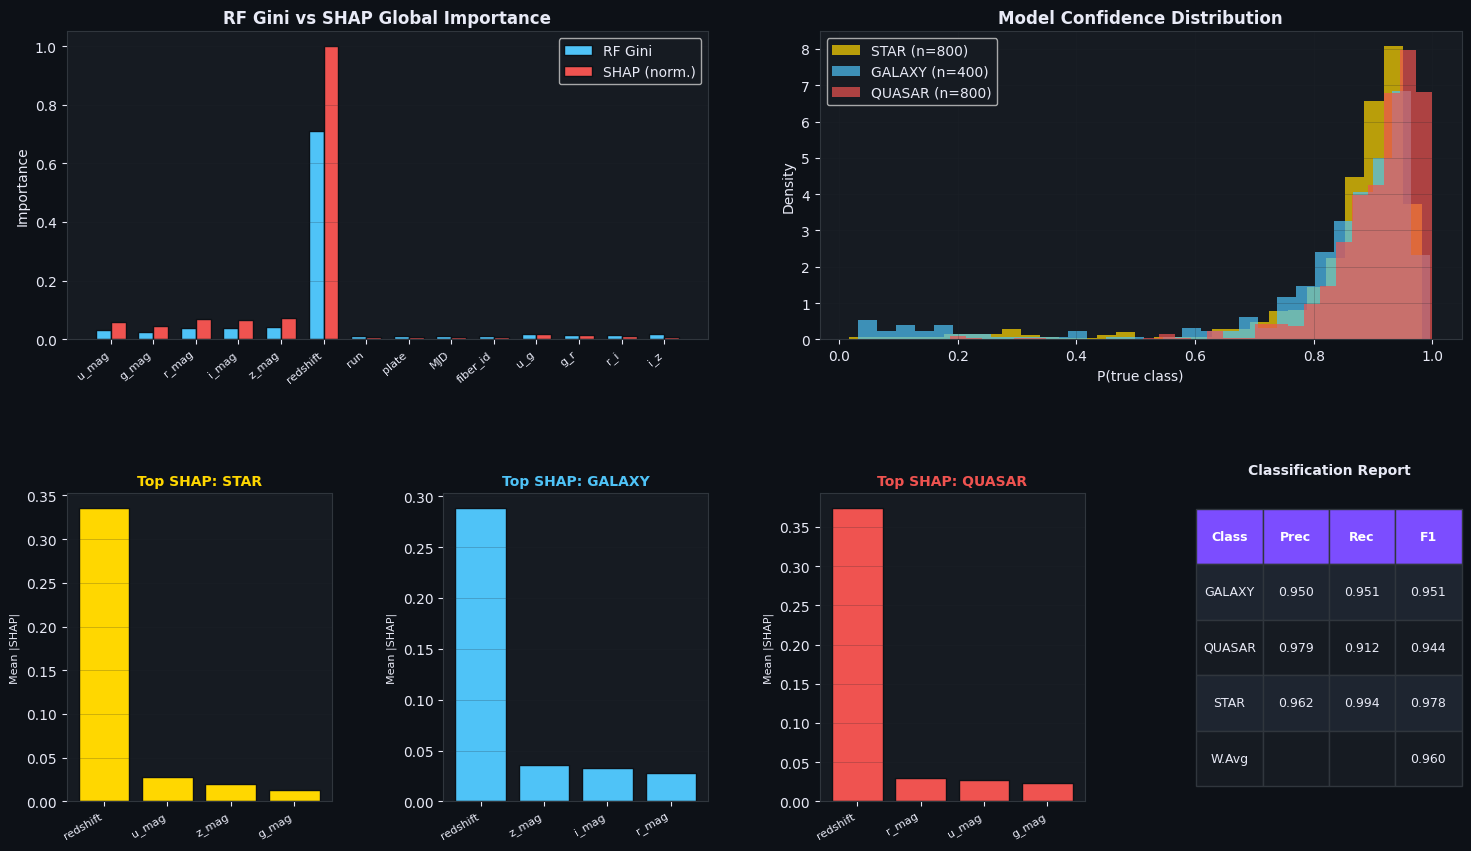

Metrics saved to metrics.json


In [ ]:
fig = plt.figure(figsize=(18,10)); fig.patch.set_facecolor(COLORS['bg'])
gs  = gridspec.GridSpec(2,4,figure=fig,hspace=0.5,wspace=0.42)

# Top Left: RF Gini vs SHAP
ax_a = fig.add_subplot(gs[0,:2])
rf_imp = rf.feature_importances_
shap_g = np.abs(shap_vals).mean(axis=(0,2))
shap_gn = shap_g / shap_g.max()
x = np.arange(len(FEAT)); w=0.35
ax_a.bar(x-w/2,rf_imp,w,label='RF Gini',color=COLORS['GALAXY'],edgecolor=COLORS['bg'])
ax_a.bar(x+w/2,shap_gn,w,label='SHAP (norm.)',color=COLORS['QUASAR'],edgecolor=COLORS['bg'])
ax_a.set_xticks(x); ax_a.set_xticklabels(FEAT,rotation=40,ha='right',fontsize=8)
ax_a.set_ylabel('Importance'); ax_a.set_title('RF Gini vs SHAP Global Importance')
ax_a.legend(facecolor=COLORS['panel']); ax_a.grid(True,axis='y',alpha=0.3)

# Top Right: Confidence Dist
ax_b = fig.add_subplot(gs[0,2:])
for ci,(cname,col) in enumerate(zip(CLASS_NAMES,CLASS_COLORS)):
    m = y_te==ci
    ax_b.hist(y_proba[m,ci],bins=30,alpha=0.7,color=col,
              label=f'{cname} (n={m.sum()})',density=True,edgecolor='none')
ax_b.set_title('Model Confidence Distribution'); ax_b.set_xlabel('P(true class)')
ax_b.set_ylabel('Density'); ax_b.legend(facecolor=COLORS['panel']); ax_b.grid(True,alpha=0.3)

# Bottom Row: Top SHAP per class
for ci,(cname,col) in enumerate(zip(CLASS_NAMES,CLASS_COLORS)):
    ax = fig.add_subplot(gs[1,ci])
    ms = np.abs(sv_cls(ci)).mean(axis=0)
    t4 = np.argsort(ms)[-4:][::-1]
    ax.bar(range(4),ms[t4],color=col,edgecolor=COLORS['bg'])
    ax.set_xticks(range(4)); ax.set_xticklabels([FEAT[i] for i in t4],rotation=30,ha='right',fontsize=8)
    ax.set_title(f'Top SHAP: {cname}',color=col,fontsize=10)
    ax.set_ylabel('Mean |SHAP|',fontsize=8); ax.grid(True,axis='y',alpha=0.3)

# Bottom Right: Class Report Table
ax_f = fig.add_subplot(gs[1,3]); ax_f.axis('off')
rpt = classification_report(y_te,y_pred,target_names=le.classes_,output_dict=True)
rows = [['Class','Prec','Rec','F1']]
for cn in le.classes_:
    m=rpt[cn]; rows.append([cn,f"{m['precision']:.3f}",f"{m['recall']:.3f}",f"{m['f1-score']:.3f}"])
rows.append(['W.Avg','','',f"{rpt['weighted avg']['f1-score']:.3f}"])
tbl = ax_f.table(cellText=rows[1:],colLabels=rows[0],cellLoc='center',loc='center',bbox=[0,0.05,1,0.9])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c),cell in tbl.get_celld().items():
    cell.set_facecolor(COLORS['panel'] if r%2==0 else '#1E2530')
    cell.set_edgecolor('#30363D'); cell.set_text_props(color=COLORS['text'])
    if r==0: cell.set_facecolor(COLORS['accent']); cell.set_text_props(color='white',fontweight='bold')
ax_f.set_title('Classification Report',fontsize=10,fontweight='bold',pad=14)

plt.tight_layout()
plt.show()

# Export Metrics
metrics_out = dict(
    accuracy=float(acc), f1_weighted=float(f1),
    cv_mean=float(cv.mean()), cv_std=float(cv.std()),
    n_train=int(X_tr.shape[0]), n_test=int(X_te.shape[0]),
    n_features=len(FEAT), feature_names=FEAT, class_names=list(le.classes_),
    shap_top3={cn:[FEAT[i] for i in np.argsort(np.abs(sv_cls(ci)).mean(axis=0))[::-1][:3]]
               for ci,cn in enumerate(le.classes_)}
)
with open('metrics.json','w') as f: json.dump(metrics_out,f,indent=2)
print("Metrics saved to metrics.json")